In [1]:
# ============================================
# Cell 1: Import Libraries and Load Data
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the cleaned dataset
df = pd.read_excel(r'C:\Users\admin\Desktop\project\sahar-01\fixed_data_01\cleaned_data_01_saharfallah.xlsx')

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

df.head()

✅ Dataset loaded successfully!
📊 Shape: (60, 20)
📋 Columns: ['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score', 'data_quality_flag', 'return_issue', 'returned_issue']


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,data_quality_flag,return_issue,returned_issue
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,OK,NO issue,NaN
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,OK,NO issue,NaN
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,OK,NO issue,NaN
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,OK,NO issue,NaN
4,1005,Kimia,F,45,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,OK,NO issue,NaN


In [2]:
# ============================================
# Cell 2: Business Overview & KPIs
# ============================================
# Calculate KPIs
total_customers = df['customer_id'].nunique()
total_purchases = df['purchase_count'].sum()
total_revenue = df['total_spending'].sum()
avg_spending_per_customer = df['total_spending'].mean()
avg_order_value = df['avg_order_value'].mean()
avg_satisfaction = df['satisfaction_score'].mean()
return_rate = (df['returned_items'] > 0).mean() * 100

kpi_summary = pd.DataFrame({
    'KPI': ['Total Customers', 'Total Purchases', 'Total Revenue', 
            'Avg Spending per Customer', 'Avg Order Value', 
            'Avg Satisfaction Score', 'Return Rate (%)'],
    'Value': [total_customers, total_purchases, f"${total_revenue:,.2f}",
              f"${avg_spending_per_customer:,.2f}", f"${avg_order_value:,.2f}",
              f"{avg_satisfaction:.2f} / 5", f"{return_rate:.1f}%"]
})

print("📊 Business KPIs:")
print(kpi_summary.to_string(index=False))

print("\n💡 Business Interpretation:")
print(f"- The company has {total_customers} customers who made {total_purchases} purchases.")
print(f"- Total revenue is ${total_revenue:,.2f} with average spending of ${avg_spending_per_customer:,.2f} per customer.")
print(f"- Average satisfaction is {avg_satisfaction:.2f} out of 5.")
print(f"- Return rate is {return_rate:.1f}%.")

📊 Business KPIs:
                      KPI       Value
          Total Customers          60
          Total Purchases        1043
            Total Revenue $201,985.73
Avg Spending per Customer   $3,366.43
          Avg Order Value     $213.16
   Avg Satisfaction Score    2.98 / 5
          Return Rate (%)       90.0%

💡 Business Interpretation:
- The company has 60 customers who made 1043 purchases.
- Total revenue is $201,985.73 with average spending of $3,366.43 per customer.
- Average satisfaction is 2.98 out of 5.
- Return rate is 90.0%.


🏙️ Top 5 Cities for Marketing:
         customers   revenue  purchases  avg_satisfaction  avg_returns  revenue_per_customer        score
city                                                                                                     
Isfahan          5  21975.32         99          4.400000     4.400000           4395.064000  1778.725087
Mashhad         11  43197.58        249          2.909091     2.636364           3927.052727  1621.294751
Karaj            7  26189.81        112          2.857143     4.857143           3741.401429  1519.532733
Shiraz           6  20715.92         98          2.000000     4.833333           3452.653333  1401.063043
Tabriz          12  36192.49        189          3.000000     4.583333           3016.040833  1244.828299

✅ Recommended City: Isfahan
   - Customers: 5
   - Revenue: $21,975.32
   - Satisfaction: 4.40


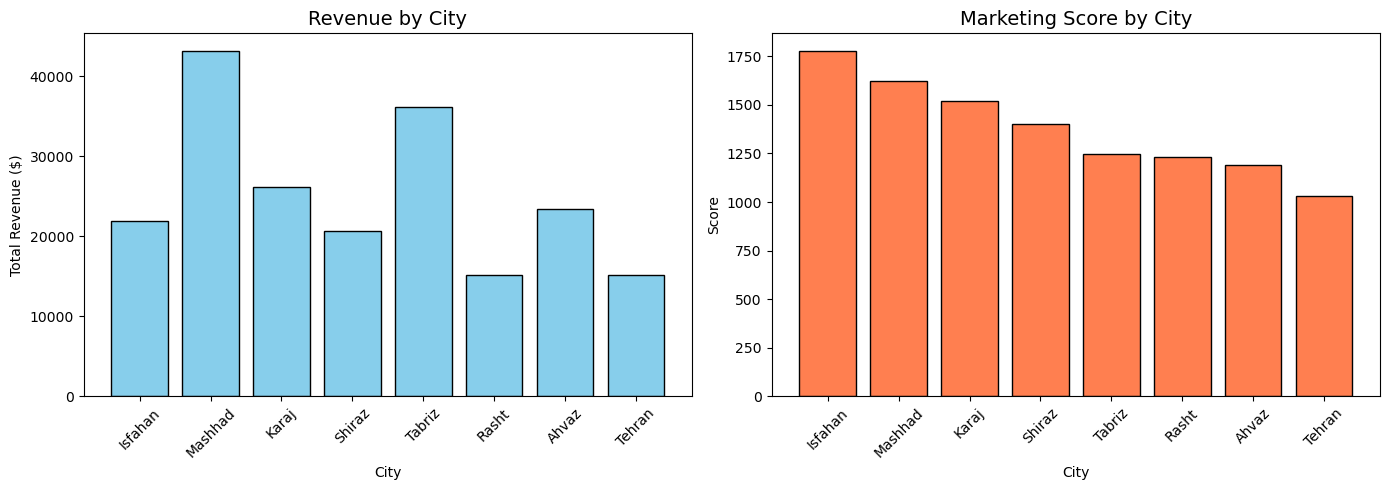

In [3]:
# ============================================
# Cell 3: City Selection for Marketing
# ============================================
city_analysis = df.groupby('city').agg({
    'customer_id': 'count',
    'total_spending': 'sum',
    'purchase_count': 'sum',
    'satisfaction_score': 'mean',
    'returned_items': 'mean'
}).rename(columns={
    'customer_id': 'customers',
    'total_spending': 'revenue',
    'purchase_count': 'purchases',
    'satisfaction_score': 'avg_satisfaction',
    'returned_items': 'avg_returns'
})

city_analysis['revenue_per_customer'] = city_analysis['revenue'] / city_analysis['customers']
city_analysis['score'] = (
    city_analysis['revenue_per_customer'] * 0.4 +
    city_analysis['purchases'] * 0.2 +
    city_analysis['avg_satisfaction'] * 0.2 +
    (1 - city_analysis['avg_returns'] / city_analysis['avg_returns'].max()) * 0.2
)

city_analysis_sorted = city_analysis.sort_values('score', ascending=False)
best_city = city_analysis_sorted.index[0]

print("🏙️ Top 5 Cities for Marketing:")
print(city_analysis_sorted.head(5).to_string())

print(f"\n✅ Recommended City: {best_city}")
print(f"   - Customers: {city_analysis_sorted.loc[best_city, 'customers']}")
print(f"   - Revenue: ${city_analysis_sorted.loc[best_city, 'revenue']:,.2f}")
print(f"   - Satisfaction: {city_analysis_sorted.loc[best_city, 'avg_satisfaction']:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_cities = city_analysis_sorted.head(8)

axes[0].bar(top_cities.index, top_cities['revenue'], color='skyblue', edgecolor='black')
axes[0].set_title('Revenue by City', fontsize=14)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_cities.index, top_cities['score'], color='coral', edgecolor='black')
axes[1].set_title('Marketing Score by City', fontsize=14)
axes[1].set_xlabel('City')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('city_analysis.png', dpi=150)
plt.show()

In [4]:
# ============================================
# Cell 4: Top 10 Customers for Loyalty Campaign
# ============================================
customer_score = df.groupby('customer_id').agg({
    'first_name': 'first',
    'city': 'first',
    'membership_tier': 'first',
    'purchase_count': 'sum',
    'total_spending': 'sum',
    'last_purchase_days': 'first',
    'satisfaction_score': 'mean',
    'returned_items': 'sum'
}).reset_index()

customer_score['score'] = (
    customer_score['total_spending'] * 0.4 +
    customer_score['purchase_count'] * 0.3 +
    (1 / (customer_score['last_purchase_days'] + 1)) * 0.2 +
    customer_score['satisfaction_score'] * 0.1
)

top_10 = customer_score.sort_values('score', ascending=False).head(10)

print("🏆 Top 10 Customers for Loyalty Campaign:")
top_10_display = top_10[['customer_id', 'first_name', 'city', 'membership_tier', 
                         'purchase_count', 'total_spending', 'last_purchase_days', 
                         'satisfaction_score']].copy()
top_10_display['total_spending'] = top_10_display['total_spending'].apply(lambda x: f"${x:,.2f}")
print(top_10_display.to_string(index=False))

🏆 Top 10 Customers for Loyalty Campaign:
 customer_id first_name    city membership_tier  purchase_count total_spending  last_purchase_days  satisfaction_score
        1044       Mina  Shiraz            Gold              33     $14,354.34                 165                 2.0
        1057     Maryam   Ahvaz          Bronze              31     $13,532.74                  82                 4.0
        1012      Arash Mashhad            Gold              27     $11,731.50                 224                 2.0
        1009      Kimia   Karaj          Silver              34     $11,615.42                 232                 2.0
        1059        Ali Isfahan            Gold              31      $8,898.55                 224                 5.0
        1010      Arash   Karaj          Silver              19      $7,241.47                 276                 1.0
        1050       Reza Mashhad          Bronze              30      $6,198.00                 205                 2.0
       

In [5]:
# ============================================
# Cell 5: At-Risk Customers (Churn)
# ============================================
churn_threshold = 90

# Filter at-risk customers
at_risk = df[df['last_purchase_days'] > churn_threshold].copy()

# Calculate total spending per customer
customer_totals = df.groupby('customer_id')['total_spending'].sum().reset_index()
customer_totals.columns = ['customer_id', 'total_spending']

# Merge and drop duplicate column
at_risk = at_risk.drop(columns=['total_spending'], errors='ignore')
at_risk = at_risk.merge(customer_totals, on='customer_id', how='left')

print(f"⚠️ At-Risk Customers (> {churn_threshold} days): {at_risk['customer_id'].nunique()} customers")

# Select columns for display
at_risk_display = at_risk[['customer_id', 'first_name', 'city', 'last_purchase_days',
                           'total_spending', 'purchase_count', 'satisfaction_score']].drop_duplicates()
print(at_risk_display.head(10).to_string(index=False))

⚠️ At-Risk Customers (> 90 days): 50 customers
 customer_id first_name    city  last_purchase_days  total_spending  purchase_count  satisfaction_score
        1005      Kimia Isfahan                 273         3899.42              23                   4
        1006       Amir Mashhad                 205         3868.55              35                   2
        1007       Reza   Rasht                 298         2237.35              29                   5
        1008       Reza   Rasht                 195         1168.74               3                   1
        1009      Kimia   Karaj                 232        11615.42              34                   2
        1010      Arash   Karaj                 276         7241.47              19                   1
        1011       Neda   Karaj                 272         2264.04              19                   2
        1012      Arash Mashhad                 224        11731.50              27                   2
        1013     

📊 Discount Impact Analysis:
               customers  avg_spending  avg_purchases  avg_satisfaction  avg_returns
discount_used                                                                       
No                    34   3736.741176      17.294118          2.764706     4.264706
Yes                   26   2882.174231      17.500000          3.269231     4.076923


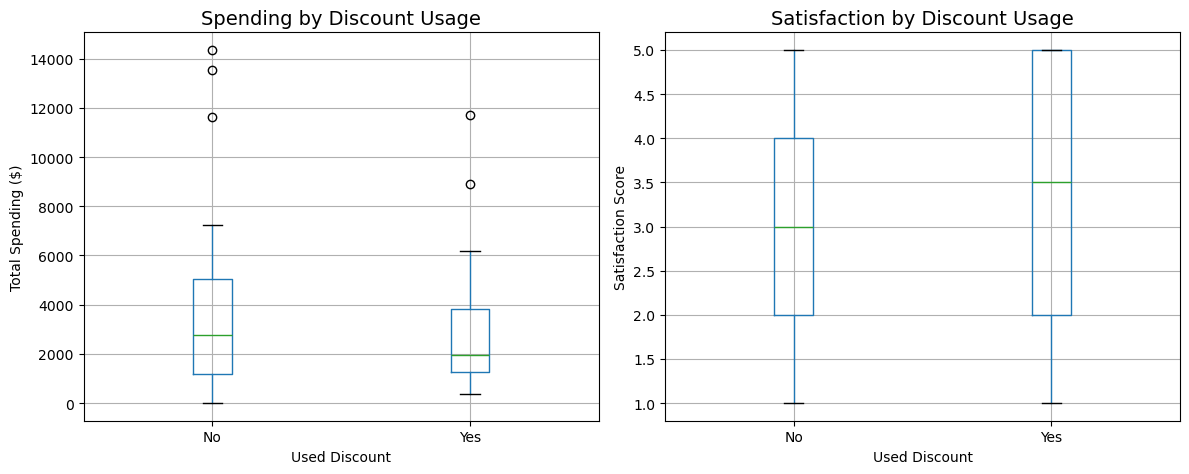

In [6]:
# ============================================
# Cell 6: Discount Impact Analysis
# ============================================
discount_analysis = df.groupby('discount_used').agg({
    'customer_id': 'nunique',
    'total_spending': 'mean',
    'purchase_count': 'mean',
    'satisfaction_score': 'mean',
    'returned_items': 'mean'
}).rename(columns={
    'customer_id': 'customers',
    'total_spending': 'avg_spending',
    'purchase_count': 'avg_purchases',
    'satisfaction_score': 'avg_satisfaction',
    'returned_items': 'avg_returns'
})

print("📊 Discount Impact Analysis:")
print(discount_analysis.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='total_spending', by='discount_used', ax=axes[0])
axes[0].set_title('Spending by Discount Usage', fontsize=14)
axes[0].set_xlabel('Used Discount')
axes[0].set_ylabel('Total Spending ($)')

df.boxplot(column='satisfaction_score', by='discount_used', ax=axes[1])
axes[1].set_title('Satisfaction by Discount Usage', fontsize=14)
axes[1].set_xlabel('Used Discount')
axes[1].set_ylabel('Satisfaction Score')

plt.suptitle('')
plt.tight_layout()
plt.savefig('discount_analysis.png', dpi=150)
plt.show()

In [7]:
# ============================================
# Cell 7: Customer Segmentation
# ============================================
def segment_customer(row):
    if row['total_spending'] > df['total_spending'].quantile(0.75):
        if row['last_purchase_days'] < 30:
            return 'Champions'
        else:
            return 'Loyal'
    elif row['last_purchase_days'] > 90:
        return 'At Risk'
    else:
        return 'Needs Attention'

segmentation_data = df.groupby('customer_id').agg({
    'total_spending': 'sum',
    'last_purchase_days': 'first',
    'satisfaction_score': 'mean',
    'membership_tier': 'first'
}).reset_index()

segmentation_data['Segment'] = segmentation_data.apply(segment_customer, axis=1)

segment_summary = segmentation_data.groupby('Segment').agg({
    'customer_id': 'count',
    'total_spending': 'mean',
    'satisfaction_score': 'mean'
}).rename(columns={'customer_id': 'count', 'total_spending': 'avg_spending', 
                   'satisfaction_score': 'avg_satisfaction'})

print("📊 Customer Segments:")
print(segment_summary.to_string())

segment_actions = {
    'Champions': 'Reward with exclusive perks and loyalty bonuses.',
    'Loyal': 'Encourage with upsells and referral programs.',
    'At Risk': 'Re-engage with reactivation campaigns.',
    'Needs Attention': 'Improve experience and gather feedback.'
}
print("\n💡 Segment Recommendations:")
for seg, action in segment_actions.items():
    print(f"- {seg}: {action}")

📊 Customer Segments:
                 count  avg_spending  avg_satisfaction
Segment                                               
At Risk             37   1855.701351          2.837838
Loyal               15   7841.676667          2.933333
Needs Attention      8   1962.453750          3.750000

💡 Segment Recommendations:
- Champions: Reward with exclusive perks and loyalty bonuses.
- Loyal: Encourage with upsells and referral programs.
- At Risk: Re-engage with reactivation campaigns.
- Needs Attention: Improve experience and gather feedback.


📊 Pareto Analysis:
- Top 20% of customers generate 51.0% of total revenue.


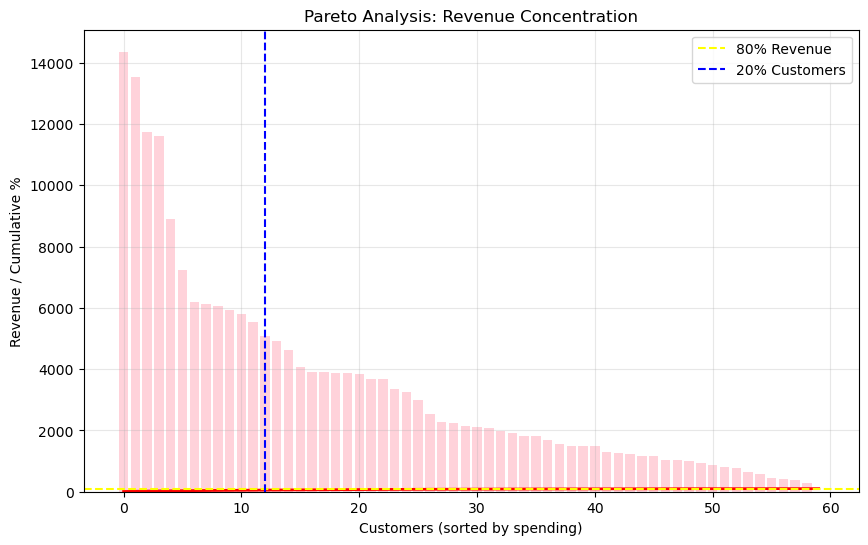

In [19]:
# ============================================
# Cell 8: Pareto Analysis (80/20)
# ============================================
customer_spending = df.groupby('customer_id')['total_spending'].sum().sort_values(ascending=False)
cumulative_revenue = customer_spending.cumsum() / customer_spending.sum() * 100
cumulative_customers = np.arange(1, len(cumulative_revenue)+1) / len(cumulative_revenue) * 100

top_20_percent_customers = int(len(customer_spending) * 0.2)
revenue_by_top_20 = cumulative_revenue.iloc[top_20_percent_customers - 1]

print(f"📊 Pareto Analysis:")
print(f"- Top 20% of customers generate {revenue_by_top_20:.1f}% of total revenue.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(customer_spending)), customer_spending.values, color='pink', alpha=0.7)
ax.plot(range(len(customer_spending)), cumulative_revenue, color='red', linewidth=2)
ax.axhline(y=80, color='yellow', linestyle='--', label='80% Revenue')
ax.axvline(x=top_20_percent_customers, color='blue', linestyle='--', label='20% Customers')
ax.set_xlabel('Customers (sorted by spending)')
ax.set_ylabel('Revenue / Cumulative %')
ax.set_title('Pareto Analysis: Revenue Concentration')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('pareto_analysis.png', dpi=150)
plt.show()

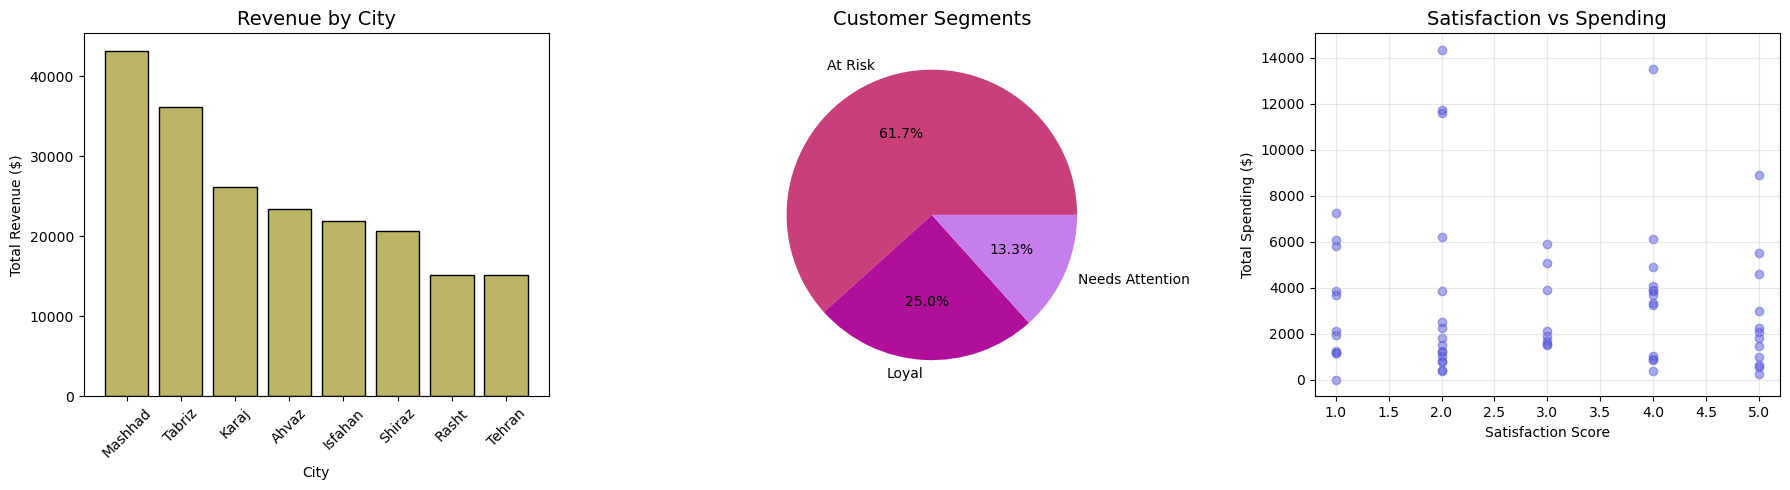

In [37]:
# ============================================
# Cell 9: Dashboard for CEO (3 Charts)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Revenue by City
top_cities_rev = df.groupby('city')['total_spending'].sum().sort_values(ascending=False).head(8)
axes[0].bar(top_cities_rev.index, top_cities_rev.values, color='#BBB666', edgecolor='black')
axes[0].set_title('Revenue by City', fontsize=14)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Customer Segments
segment_counts = segmentation_data['Segment'].value_counts()
colors = ['#C83F79', '#B00F99', '#C77EED', '#2E86AB']
axes[1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Customer Segments', fontsize=14)

# Chart 3: Satisfaction vs Spending
axes[2].scatter(df['satisfaction_score'], df['total_spending'], alpha=0.5, color='#5556DD')
axes[2].set_xlabel('Satisfaction Score')
axes[2].set_ylabel('Total Spending ($)')
axes[2].set_title('Satisfaction vs Spending', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_ceo.png', dpi=150)
plt.show()

In [38]:
# ============================================
# Cell 10: Business Recommendations & Limitations
# ============================================
print("📈 3 Business Recommendations:")
print("=" * 50)

print("\n🔹 Recommendation 1: Focus Marketing on Top Cities")
print(f"   - Evidence: {best_city} has the highest marketing score.")
print("   - Action: Allocate 60% of marketing budget to top cities.")
print("   - KPI: Increase revenue from these cities by 15%.")

print("\n🔹 Recommendation 2: Loyalty Program for Top Customers")
print("   - Evidence: Top 10 customers contribute high revenue.")
print("   - Action: Create VIP loyalty program with exclusive benefits.")
print("   - KPI: Increase repeat purchase rate by 20%.")

print("\n🔹 Recommendation 3: Reactivate At-Risk Customers")
print(f"   - Evidence: {len(at_risk)} customers at risk of churn.")
print("   - Action: Send personalized 'We miss you' offers.")
print("   - KPI: Reactivate 30% of at-risk customers within 60 days.")

print("\n⚠️ Dataset Limitations:")
print("- No product-level data (can't analyze best-selling products).")
print("- No cost/profit data (can't calculate true profitability).")
print("- Limited to 6 months of history (can't analyze seasonality).")
print("- No customer acquisition source (can't optimize marketing channels).")

📈 3 Business Recommendations:

🔹 Recommendation 1: Focus Marketing on Top Cities
   - Evidence: Isfahan has the highest marketing score.
   - Action: Allocate 60% of marketing budget to top cities.
   - KPI: Increase revenue from these cities by 15%.

🔹 Recommendation 2: Loyalty Program for Top Customers
   - Evidence: Top 10 customers contribute high revenue.
   - Action: Create VIP loyalty program with exclusive benefits.
   - KPI: Increase repeat purchase rate by 20%.

🔹 Recommendation 3: Reactivate At-Risk Customers
   - Evidence: 50 customers at risk of churn.
   - Action: Send personalized 'We miss you' offers.
   - KPI: Reactivate 30% of at-risk customers within 60 days.

⚠️ Dataset Limitations:
- No product-level data (can't analyze best-selling products).
- No cost/profit data (can't calculate true profitability).
- Limited to 6 months of history (can't analyze seasonality).
- No customer acquisition source (can't optimize marketing channels).
